In [1]:
import numpy as np
import pandas as pd
import hdbscan
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd 
import os

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA  # <-- Missing import
import matplotlib.pyplot as plt
#data load
raw_counts = pd.read_csv("gene_counts _for_ml.csv", index_col=0)

In [2]:
raw_counts.head()

,TREATMENT,TREATMENT.1,TREATMENT.2,TREATMENT.3,CONTROL,CONTROL.1,CONTROL.2,CONTROL.3
GeneID,,,,,,,,
LOC101497325,35,32,56,39,52,23,58,13
LOC101488339,107,86,102,105,74,117,84,58
LOC101488545,192,307,324,243,247,292,212,169
LOC101497647,134,402,568,753,267,549,78,182
LOC101489113,1820,2415,3567,3324,2479,3055,2467,1370


In [3]:
raw_counts.columns = raw_counts.columns.str.replace(r'^(CONTROL|TREATMENT).*', r'\1', regex=True)
print("\nCleaned columns:")
print(raw_counts.columns)


Cleaned columns:
Index(['TREATMENT', 'TREATMENT', 'TREATMENT', 'TREATMENT', 'CONTROL',
       'CONTROL', 'CONTROL', 'CONTROL'],
      dtype='object')


In [4]:
raw_counts.head()
raw_counts.info

<bound method DataFrame.info of               TREATMENT  TREATMENT  TREATMENT  TREATMENT  CONTROL  CONTROL  \
GeneID                                                                       
LOC101497325         35         32         56         39       52       23   
LOC101488339        107         86        102        105       74      117   
LOC101488545        192        307        324        243      247      292   
LOC101497647        134        402        568        753      267      549   
LOC101489113       1820       2415       3567       3324     2479     3055   
...                 ...        ...        ...        ...      ...      ...   
CiarC_p072            0          0          0          0        0        0   
CiarC_p073            0          0          0          0        0        0   
CiarC_t029            0          0          0          0        0        0   
CiarC_p074            0          0          0          0        0        0   
CiarC_p075            0         

In [5]:
filtered_df= raw_counts

For 3k of genes using Manhattan distnce in HDBSCAN

Original data shape: (28581, 8)
Top variable genes shape: (3000, 8)

Running with min_cluster_size=10, min_samples=10


/home/shafeeq/Downloads/yes/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/shafeeq/Downloads/yes/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Running with min_cluster_size=10, min_samples=20


/home/shafeeq/Downloads/yes/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/shafeeq/Downloads/yes/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Running with min_cluster_size=10, min_samples=30


...


Running with min_cluster_size=100, min_samples=90


/home/shafeeq/Downloads/yes/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/shafeeq/Downloads/yes/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Running with min_cluster_size=100, min_samples=100


/home/shafeeq/Downloads/yes/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/shafeeq/Downloads/yes/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

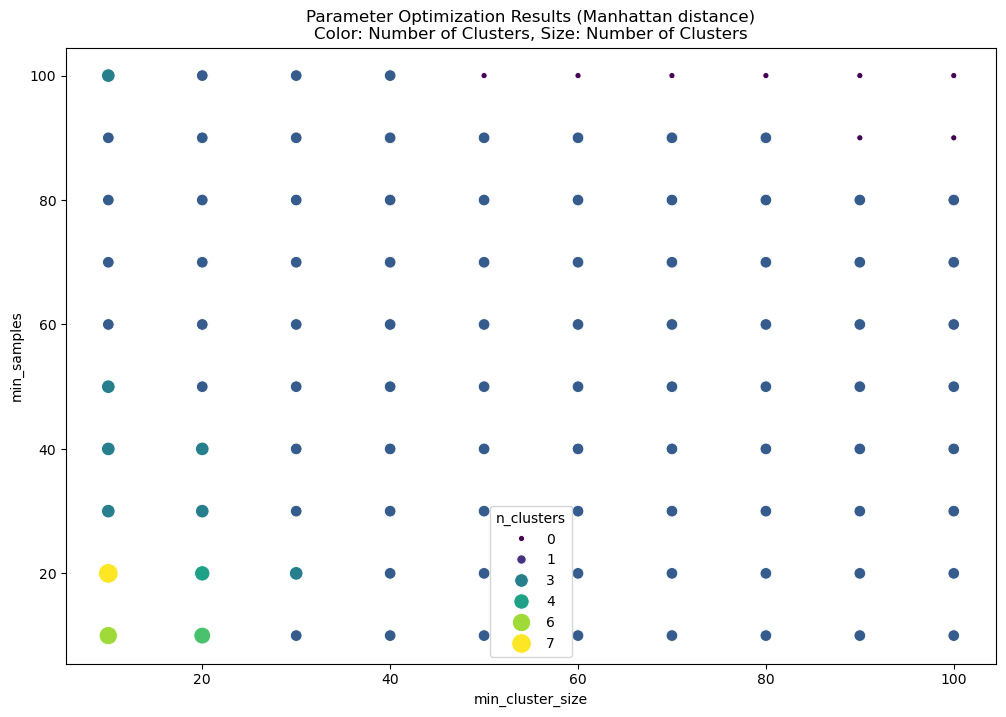

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import hdbscan
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from matplotlib.colors import LinearSegmentedColormap

# Create output directory
output_dir = "final_results/PCA_optimization_visulaization_with_3K_manhattan"
os.makedirs(output_dir, exist_ok=True)

# Create custom red colormap
colors = [(0, 'white'), (0.5, 'lightcoral'), (1, 'darkred')]
red_cmap = LinearSegmentedColormap.from_list('red_cmap', colors)

# Assuming filtered_df is your original count matrix (genes × samples)
print(f"Original data shape: {filtered_df.shape}")

# 1. Log-normalization
normalized_data = np.log2(filtered_df + 1)

# 2. Select top variable genes
gene_variability = normalized_data.std(axis=1)
top_genes_idx = gene_variability.sort_values(ascending=False).head(3000).index
top_variable_data = normalized_data.loc[top_genes_idx]

print(f"Top variable genes shape: {top_variable_data.shape}")

# 3. Z-score normalization
top_variable_scaled = pd.DataFrame(
    StandardScaler().fit_transform(top_variable_data),
    index=top_genes_idx,
    columns=top_variable_data.columns
)

# Parameter ranges
min_cluster_sizes = range(10, 101, 10)
min_samples_range = range(10, 101, 10)

# Store optimization results
optimization_results = []

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_range:
        print(f"\nRunning with min_cluster_size={min_cluster_size}, min_samples={min_samples}")
        
        param_dir = os.path.join(output_dir, f"min_cluster_{min_cluster_size}_min_samples_{min_samples}")
        os.makedirs(param_dir, exist_ok=True)
        
        # HDBSCAN clustering with Manhattan distance
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            gen_min_span_tree=True,
            metric='manhattan'  # Changed from default 'euclidean' to 'manhattan'
        )
        clusters = clusterer.fit_predict(top_variable_scaled)
        
        # Store results
        optimization_results.append({
            'min_cluster_size': min_cluster_size,
            'min_samples': min_samples,
            'n_clusters': len(set(clusters)) - (1 if -1 in clusters else 0),
            'n_noise': sum(clusters == -1)
        })
        
        # Create cluster assignment dataframe
        cluster_assignments = pd.DataFrame({
            'Gene': top_variable_scaled.index,
            'Cluster': clusters
        })
        cluster_assignments.to_csv(
            os.path.join(param_dir, "all_gene_cluster_assignments.csv"),
            index=False
        )
        
        # Generate heatmaps for each cluster (including -1)
        for cluster_id in np.unique(clusters):
            cluster_name = "Outliers" if cluster_id == -1 else f"Cluster_{cluster_id}"
            cluster_genes = cluster_assignments[cluster_assignments['Cluster'] == cluster_id]['Gene']
            
            if len(cluster_genes) > 0:
                # Save gene list
                pd.DataFrame({'Gene': cluster_genes}).to_csv(
                    os.path.join(param_dir, f"{cluster_name}_genes.csv"),
                    index=False
                )
                
                # Create heatmap for this cluster
                cluster_data = top_variable_scaled.loc[cluster_genes]
                
                plt.figure(figsize=(15, 10))
                # Create gridspec to position colorbar below heatmap
                gs = plt.GridSpec(2, 1, height_ratios=[0.9, 0.1])
                ax0 = plt.subplot(gs[0])
                ax1 = plt.subplot(gs[1])
                
                # Main heatmap
                sns.heatmap(
                    cluster_data,
                    cmap=red_cmap,
                    yticklabels=False,
                    cbar=False,
                    ax=ax0,
                    center=0,
                    vmin=-3,
                    vmax=3
                )
                ax0.set_title(f"Expression Heatmap - {cluster_name} (n={len(cluster_genes)})")
                ax0.set_xlabel("")
                
                # Add colorbar below
                cbar = plt.colorbar(ax0.collections[0], cax=ax1, orientation='horizontal')
                cbar.set_label('Z-score normalized expression', labelpad=10)
                cbar.ax.xaxis.set_ticks_position('bottom')
                cbar.ax.xaxis.set_label_position('bottom')
                
                plt.tight_layout()
                plt.savefig(
                    os.path.join(param_dir, f"{cluster_name}_heatmap.png"),
                    dpi=300, bbox_inches='tight'
                )
                plt.close()
        
        # Perform PCA for visualization (still using Euclidean distance for visualization)
        pca = PCA(n_components=2)
        pca_result = pca.fit_transform(top_variable_scaled)
        pca_df = pd.DataFrame({
            'PC1': pca_result[:, 0],
            'PC2': pca_result[:, 1],
            'Cluster': clusters
        })
        
        # 1. PCA plot for all clusters
        plt.figure(figsize=(12, 8))
        unique_clusters = np.unique(clusters)
        palette = sns.color_palette("hsv", len(unique_clusters)-1) + [(0.5, 0.5, 0.5)]  # Gray for outliers
        
        sns.scatterplot(
            data=pca_df,
            x='PC1',
            y='PC2',
            hue='Cluster',
            palette=palette,
            alpha=0.7,
            s=50
        )
        plt.title(f"PCA of Gene Clusters (Manhattan distance)\n(min_cluster_size={min_cluster_size}, min_samples={min_samples})")
        plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(
            os.path.join(param_dir, "pca_all_clusters.png"),
            dpi=300, bbox_inches='tight'
        )
        plt.close()
        
        # 2. PCA plot for ONLY outliers (-1 cluster)
        if -1 in clusters:
            outliers_df = pca_df[pca_df['Cluster'] == -1]
            plt.figure(figsize=(12, 8))
            sns.scatterplot(
                data=outliers_df,
                x='PC1',
                y='PC2',
                color='gray',
                alpha=0.7,
                s=50
            )
            plt.title(f"PCA of Outlier Genes Only (Manhattan distance)\n(min_cluster_size={min_cluster_size}, min_samples={min_samples}, n={len(outliers_df)})")
            plt.tight_layout()
            plt.savefig(
                os.path.join(param_dir, "pca_outliers_only.png"),
                dpi=300, bbox_inches='tight'
            )
            plt.close()
        
        # Generate dendrogram using scipy (using Manhattan distance for consistency)
        try:
            # Subsample if too many genes for dendrogram
            if len(top_variable_scaled) > 1000:
                sample_idx = np.random.choice(len(top_variable_scaled), 1000, replace=False)
                sample_data = top_variable_scaled.iloc[sample_idx]
            else:
                sample_data = top_variable_scaled
            
            # Use Manhattan distance for dendrogram as well
            distance_matrix = pdist(sample_data, 'cityblock')  # 'cityblock' is Manhattan distance
            linkage_matrix = linkage(distance_matrix, 'ward')
            
            plt.figure(figsize=(20, 12))
            dendrogram(
                linkage_matrix,
                truncate_mode='lastp',
                p=min(50, len(sample_data)),  # show only the last p merged clusters
                show_leaf_counts=True,
                leaf_rotation=90,
                leaf_font_size=8,
                show_contracted=True,
                color_threshold=0.7*max(linkage_matrix[:, 2])
            )
            
            # Add cluster colors if we have cluster assignments
            if hasattr(clusterer, 'labels_'):
                cluster_colors = [sns.color_palette("hsv", len(set(clusters)))[i] 
                                if i != -1 else (0.5, 0.5, 0.5)
                                for i in clusters[sample_idx]]
                ax = plt.gca()
                xlbls = ax.get_xmajorticklabels()
                for lbl, color in zip(xlbls, cluster_colors):
                    lbl.set_color(color)
            
            plt.title(f"Gene Cluster Dendrogram (Manhattan distance)\n(min_cluster_size={min_cluster_size}, min_samples={min_samples})")
            plt.xlabel("Gene Clusters")
            plt.ylabel("Distance")
            plt.savefig(
                os.path.join(param_dir, "gene_cluster_dendrogram.png"),
                dpi=300, bbox_inches='tight'
            )
            plt.close()
        except Exception as e:
            print(f"Could not create dendrogram: {e}")

# Save optimization results
optimization_df = pd.DataFrame(optimization_results)
optimization_df.to_csv(os.path.join(output_dir, "parameter_optimization_results.csv"), index=False)

# Plot optimization summary
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=optimization_df,
    x='min_cluster_size',
    y='min_samples',
    size='n_clusters',
    hue='n_clusters',
    palette='viridis',
    sizes=(20, 200)
)
plt.title("Parameter Optimization Results (Manhattan distance)\nColor: Number of Clusters, Size: Number of Clusters")
plt.colorbar(label='Number of Clusters')
plt.savefig(os.path.join(output_dir, "parameter_optimization_summary.png"), dpi=300)
plt.close()

print(f"\nAll results saved to: {output_dir}")

For 5K of genes using Manhattan distnce in HDBSCAN

Original data shape: (28581, 8)
Top variable genes shape: (5000, 8)

Running with min_cluster_size=10, min_samples=10

Running with min_cluster_size=10, min_samples=20

Running with min_cluster_size=10, min_samples=30

Running with min_cluster_size=10, min_samples=40

Running with min_cluster_size=10, min_samples=50

Running with min_cluster_size=10, min_samples=60

Running with min_cluster_size=10, min_samples=70

Running with min_cluster_size=10, min_samples=80

Running with min_cluster_size=10, min_samples=90

Running with min_cluster_size=10, min_samples=100

Running with min_cluster_size=20, min_samples=10

Running with min_cluster_size=20, min_samples=20

Running with min_cluster_size=20, min_samples=30

Running with min_cluster_size=20, min_samples=40

Running with min_cluster_size=20, min_samples=50

Running with min_cluster_size=20, min_samples=60

Running with min_cluster_size=20, min_samples=70

Running with min_cluster_size=20, min_samples=80

Running with min_cluster_size=

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

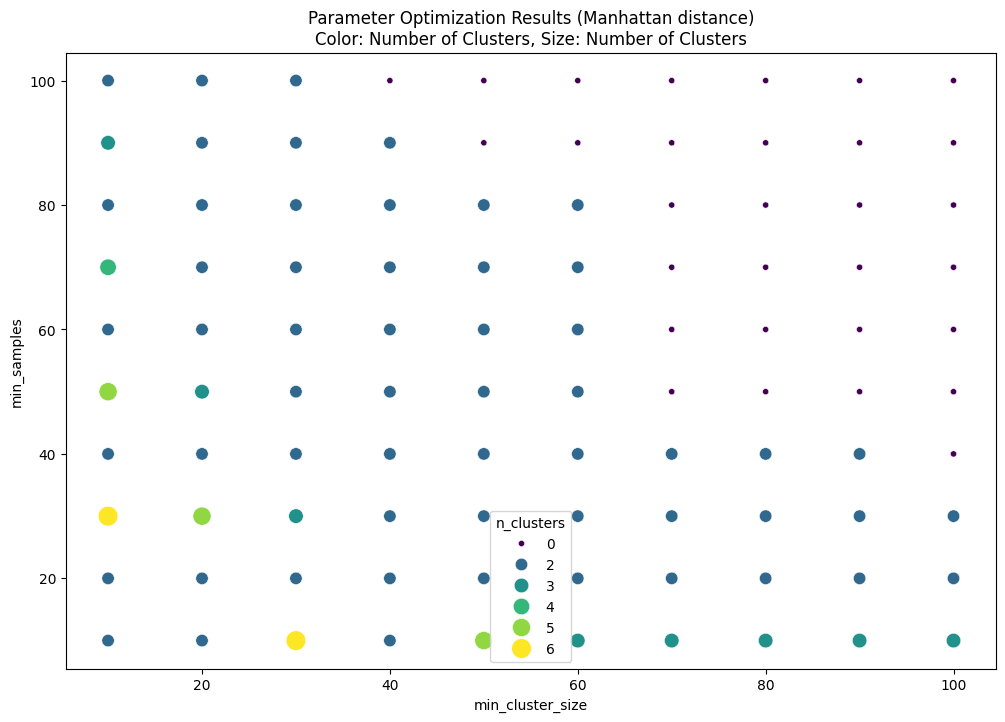

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import hdbscan
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from matplotlib.colors import LinearSegmentedColormap

# Create output directory
output_dir = "final_results/PCA_optimization_visulaization_with_5K_manhattan"
os.makedirs(output_dir, exist_ok=True)

# Create custom red colormap
colors = [(0, 'white'), (0.5, 'lightcoral'), (1, 'darkred')]
red_cmap = LinearSegmentedColormap.from_list('red_cmap', colors)

# Assuming filtered_df is your original count matrix (genes × samples)
print(f"Original data shape: {filtered_df.shape}")

# 1. Log-normalization
normalized_data = np.log2(filtered_df + 1)

# 2. Select top variable genes
gene_variability = normalized_data.std(axis=1)
top_genes_idx = gene_variability.sort_values(ascending=False).head(5000).index
top_variable_data = normalized_data.loc[top_genes_idx]

print(f"Top variable genes shape: {top_variable_data.shape}")

# 3. Z-score normalization
top_variable_scaled = pd.DataFrame(
    StandardScaler().fit_transform(top_variable_data),
    index=top_genes_idx,
    columns=top_variable_data.columns
)

# Parameter ranges
min_cluster_sizes = range(10, 101, 10)
min_samples_range = range(10, 101, 10)

# Store optimization results
optimization_results = []

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_range:
        print(f"\nRunning with min_cluster_size={min_cluster_size}, min_samples={min_samples}")
        
        param_dir = os.path.join(output_dir, f"min_cluster_{min_cluster_size}_min_samples_{min_samples}")
        os.makedirs(param_dir, exist_ok=True)
        
        # HDBSCAN clustering with Manhattan distance
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            gen_min_span_tree=True,
            metric='manhattan'  # Changed from default 'euclidean' to 'manhattan'
        )
        clusters = clusterer.fit_predict(top_variable_scaled)
        
        # Store results
        optimization_results.append({
            'min_cluster_size': min_cluster_size,
            'min_samples': min_samples,
            'n_clusters': len(set(clusters)) - (1 if -1 in clusters else 0),
            'n_noise': sum(clusters == -1)
        })
        
        # Create cluster assignment dataframe
        cluster_assignments = pd.DataFrame({
            'Gene': top_variable_scaled.index,
            'Cluster': clusters
        })
        cluster_assignments.to_csv(
            os.path.join(param_dir, "all_gene_cluster_assignments.csv"),
            index=False
        )
        
        # Generate heatmaps for each cluster (including -1)
        for cluster_id in np.unique(clusters):
            cluster_name = "Outliers" if cluster_id == -1 else f"Cluster_{cluster_id}"
            cluster_genes = cluster_assignments[cluster_assignments['Cluster'] == cluster_id]['Gene']
            
            if len(cluster_genes) > 0:
                # Save gene list
                pd.DataFrame({'Gene': cluster_genes}).to_csv(
                    os.path.join(param_dir, f"{cluster_name}_genes.csv"),
                    index=False
                )
                
                # Create heatmap for this cluster
                cluster_data = top_variable_scaled.loc[cluster_genes]
                
                plt.figure(figsize=(15, 10))
                # Create gridspec to position colorbar below heatmap
                gs = plt.GridSpec(2, 1, height_ratios=[0.9, 0.1])
                ax0 = plt.subplot(gs[0])
                ax1 = plt.subplot(gs[1])
                
                # Main heatmap
                sns.heatmap(
                    cluster_data,
                    cmap=red_cmap,
                    yticklabels=False,
                    cbar=False,
                    ax=ax0,
                    center=0,
                    vmin=-3,
                    vmax=3
                )
                ax0.set_title(f"Expression Heatmap - {cluster_name} (n={len(cluster_genes)})")
                ax0.set_xlabel("")
                
                # Add colorbar below
                cbar = plt.colorbar(ax0.collections[0], cax=ax1, orientation='horizontal')
                cbar.set_label('Z-score normalized expression', labelpad=10)
                cbar.ax.xaxis.set_ticks_position('bottom')
                cbar.ax.xaxis.set_label_position('bottom')
                
                plt.tight_layout()
                plt.savefig(
                    os.path.join(param_dir, f"{cluster_name}_heatmap.png"),
                    dpi=300, bbox_inches='tight'
                )
                plt.close()
        
        # Perform PCA for visualization (still using Euclidean distance for visualization)
        pca = PCA(n_components=2)
        pca_result = pca.fit_transform(top_variable_scaled)
        pca_df = pd.DataFrame({
            'PC1': pca_result[:, 0],
            'PC2': pca_result[:, 1],
            'Cluster': clusters
        })
        
        # 1. PCA plot for all clusters
        plt.figure(figsize=(12, 8))
        unique_clusters = np.unique(clusters)
        palette = sns.color_palette("hsv", len(unique_clusters)-1) + [(0.5, 0.5, 0.5)]  # Gray for outliers
        
        sns.scatterplot(
            data=pca_df,
            x='PC1',
            y='PC2',
            hue='Cluster',
            palette=palette,
            alpha=0.7,
            s=50
        )
        plt.title(f"PCA of Gene Clusters (Manhattan distance)\n(min_cluster_size={min_cluster_size}, min_samples={min_samples})")
        plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(
            os.path.join(param_dir, "pca_all_clusters.png"),
            dpi=300, bbox_inches='tight'
        )
        plt.close()
        
        # 2. PCA plot for ONLY outliers (-1 cluster)
        if -1 in clusters:
            outliers_df = pca_df[pca_df['Cluster'] == -1]
            plt.figure(figsize=(12, 8))
            sns.scatterplot(
                data=outliers_df,
                x='PC1',
                y='PC2',
                color='gray',
                alpha=0.7,
                s=50
            )
            plt.title(f"PCA of Outlier Genes Only (Manhattan distance)\n(min_cluster_size={min_cluster_size}, min_samples={min_samples}, n={len(outliers_df)})")
            plt.tight_layout()
            plt.savefig(
                os.path.join(param_dir, "pca_outliers_only.png"),
                dpi=300, bbox_inches='tight'
            )
            plt.close()
        
        # Generate dendrogram using scipy (using Manhattan distance for consistency)
        try:
            # Subsample if too many genes for dendrogram
            if len(top_variable_scaled) > 1000:
                sample_idx = np.random.choice(len(top_variable_scaled), 1000, replace=False)
                sample_data = top_variable_scaled.iloc[sample_idx]
            else:
                sample_data = top_variable_scaled
            
            # Use Manhattan distance for dendrogram as well
            distance_matrix = pdist(sample_data, 'cityblock')  # 'cityblock' is Manhattan distance
            linkage_matrix = linkage(distance_matrix, 'ward')
            
            plt.figure(figsize=(20, 12))
            dendrogram(
                linkage_matrix,
                truncate_mode='lastp',
                p=min(50, len(sample_data)),  # show only the last p merged clusters
                show_leaf_counts=True,
                leaf_rotation=90,
                leaf_font_size=8,
                show_contracted=True,
                color_threshold=0.7*max(linkage_matrix[:, 2])
            )
            
            # Add cluster colors if we have cluster assignments
            if hasattr(clusterer, 'labels_'):
                cluster_colors = [sns.color_palette("hsv", len(set(clusters)))[i] 
                                if i != -1 else (0.5, 0.5, 0.5)
                                for i in clusters[sample_idx]]
                ax = plt.gca()
                xlbls = ax.get_xmajorticklabels()
                for lbl, color in zip(xlbls, cluster_colors):
                    lbl.set_color(color)
            
            plt.title(f"Gene Cluster Dendrogram (Manhattan distance)\n(min_cluster_size={min_cluster_size}, min_samples={min_samples})")
            plt.xlabel("Gene Clusters")
            plt.ylabel("Distance")
            plt.savefig(
                os.path.join(param_dir, "gene_cluster_dendrogram.png"),
                dpi=300, bbox_inches='tight'
            )
            plt.close()
        except Exception as e:
            print(f"Could not create dendrogram: {e}")

# Save optimization results
optimization_df = pd.DataFrame(optimization_results)
optimization_df.to_csv(os.path.join(output_dir, "parameter_optimization_results.csv"), index=False)

# Plot optimization summary
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=optimization_df,
    x='min_cluster_size',
    y='min_samples',
    size='n_clusters',
    hue='n_clusters',
    palette='viridis',
    sizes=(20, 200)
)
plt.title("Parameter Optimization Results (Manhattan distance)\nColor: Number of Clusters, Size: Number of Clusters")
plt.colorbar(label='Number of Clusters')
plt.savefig(os.path.join(output_dir, "parameter_optimization_summary.png"), dpi=300)
plt.close()

print(f"\nAll results saved to: {output_dir}")

For complete set of genes using Manhattan distnce in HDBSCAN

Original data shape: (28581, 8)
Using all genes: (28581, 8)

Running with min_cluster_size=10, min_samples=10


/home/shafeeq/Downloads/yes/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/shafeeq/Downloads/yes/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Performing dimensionality reduction with TruncatedSVD...
Could not create dendrogram: list index out of range

Running with min_cluster_size=10, min_samples=20


/home/shafeeq/Downloads/yes/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/shafeeq/Downloads/yes/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Performing dimensionality reduction with TruncatedSVD...
Could not create dendrogram: list index out of range

Running with min_cluster_size=10, min_samples=30


...

/home/shafeeq/Downloads/yes/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/shafeeq/Downloads/yes/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Performing dimensionality reduction with TruncatedSVD...

Running with min_cluster_size=30, min_samples=30


/home/shafeeq/Downloads/yes/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/shafeeq/Downloads/yes/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Performing dimensionality reduction with TruncatedSVD...


RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

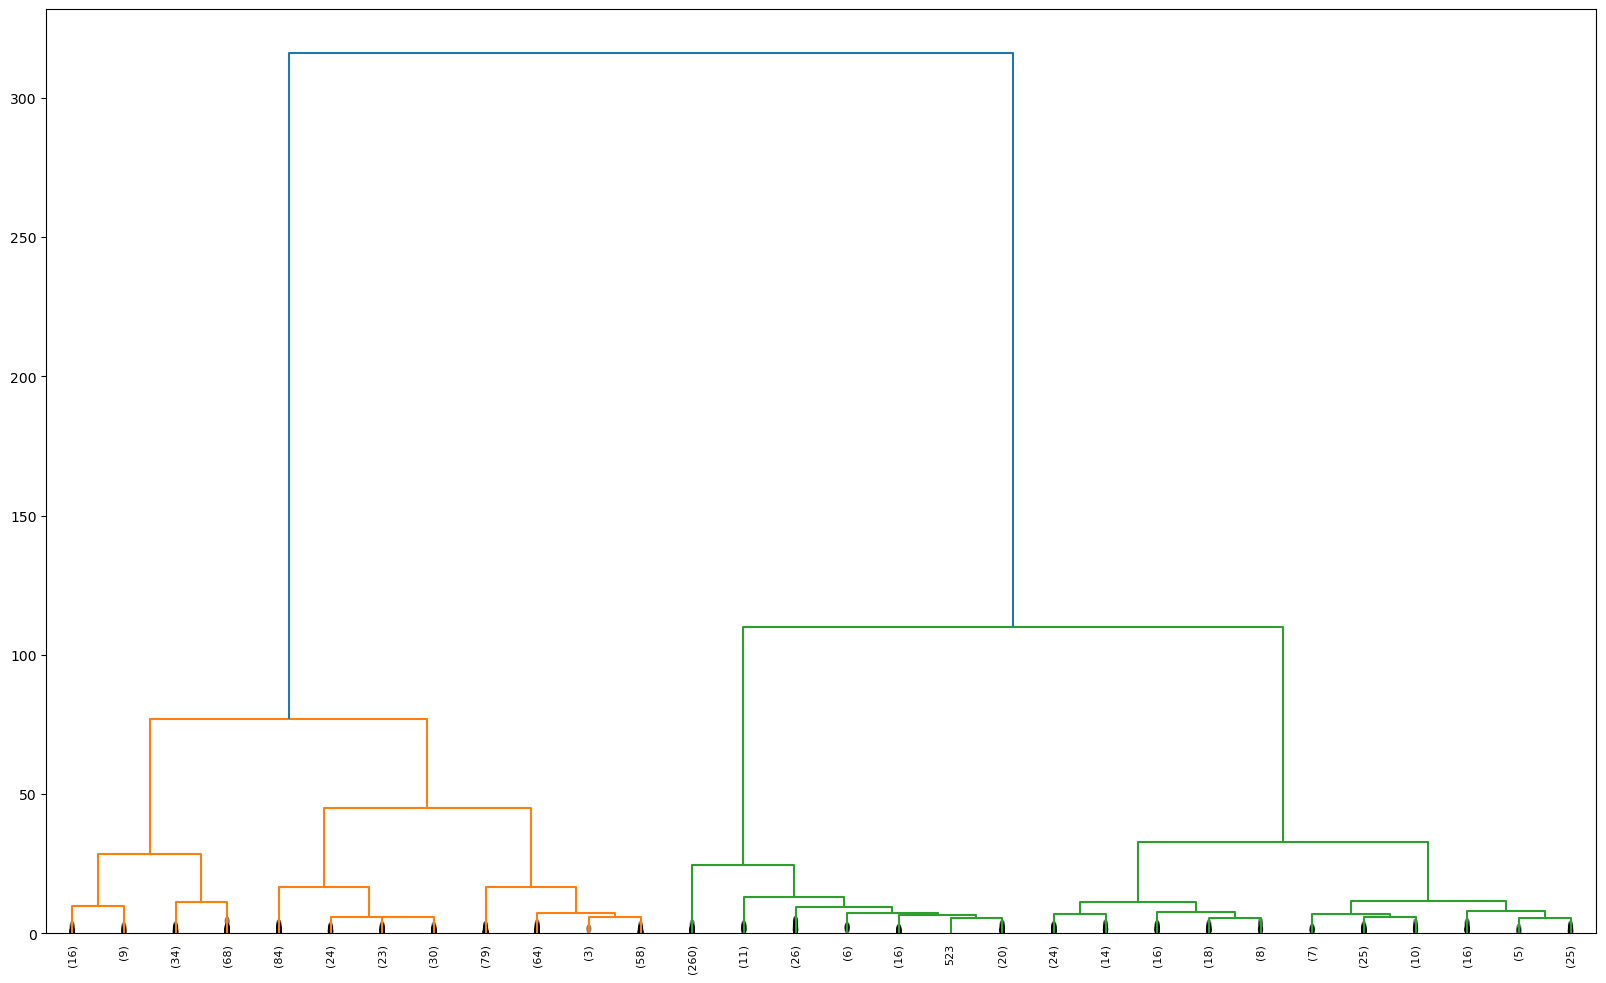

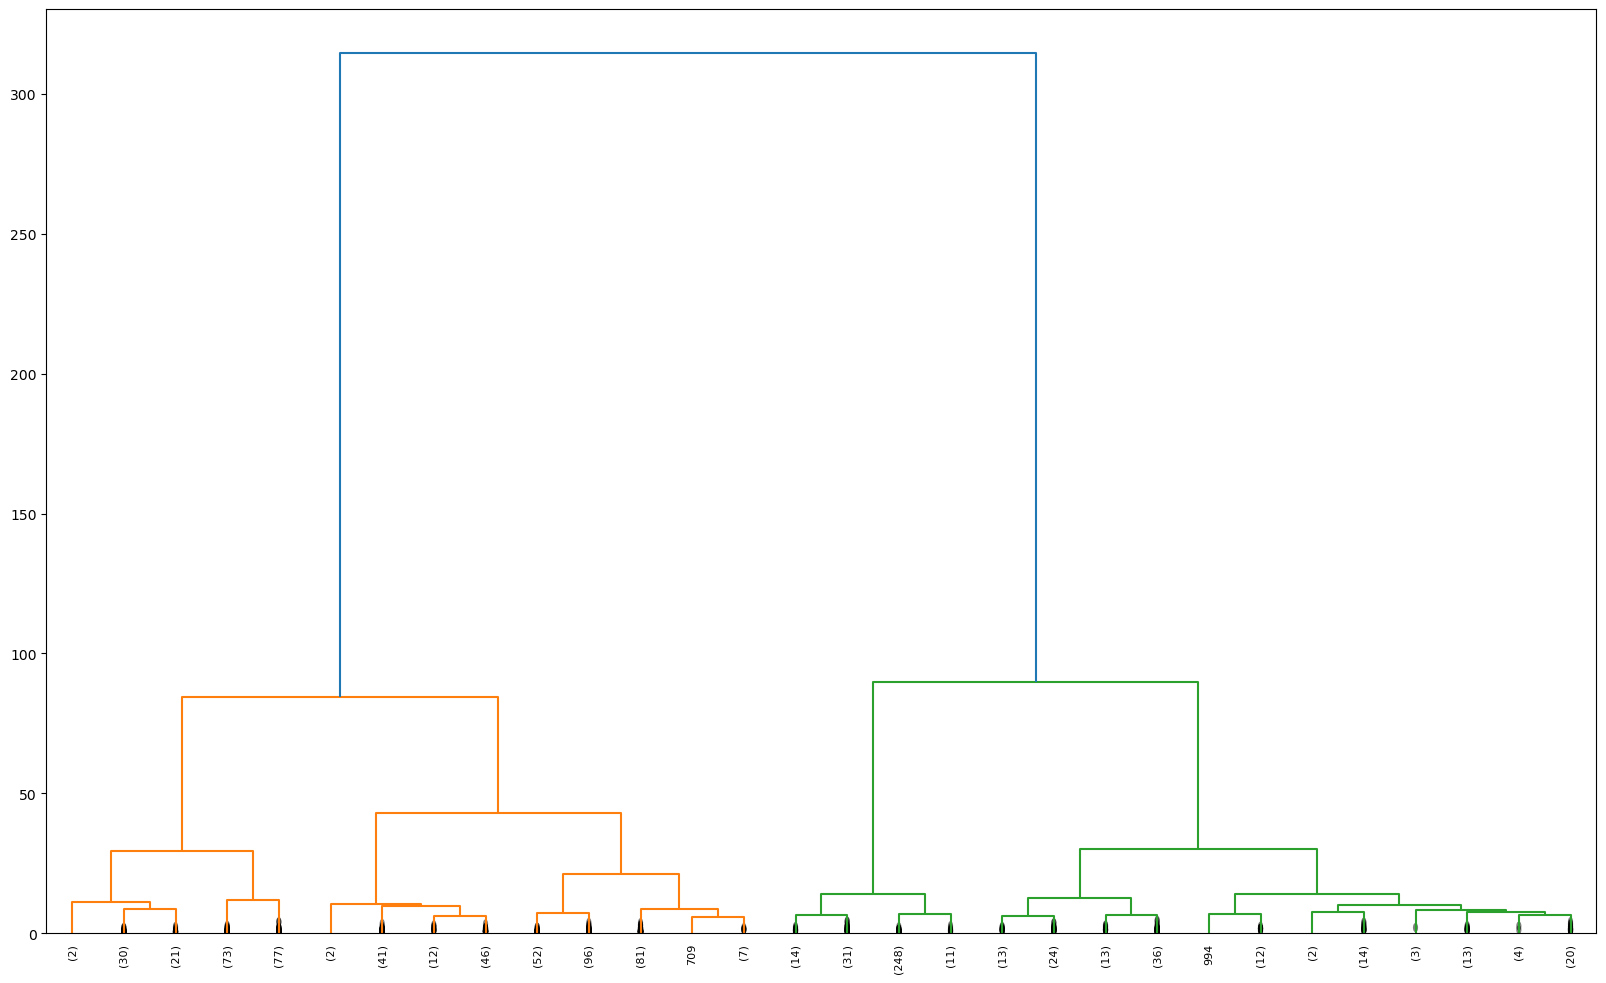

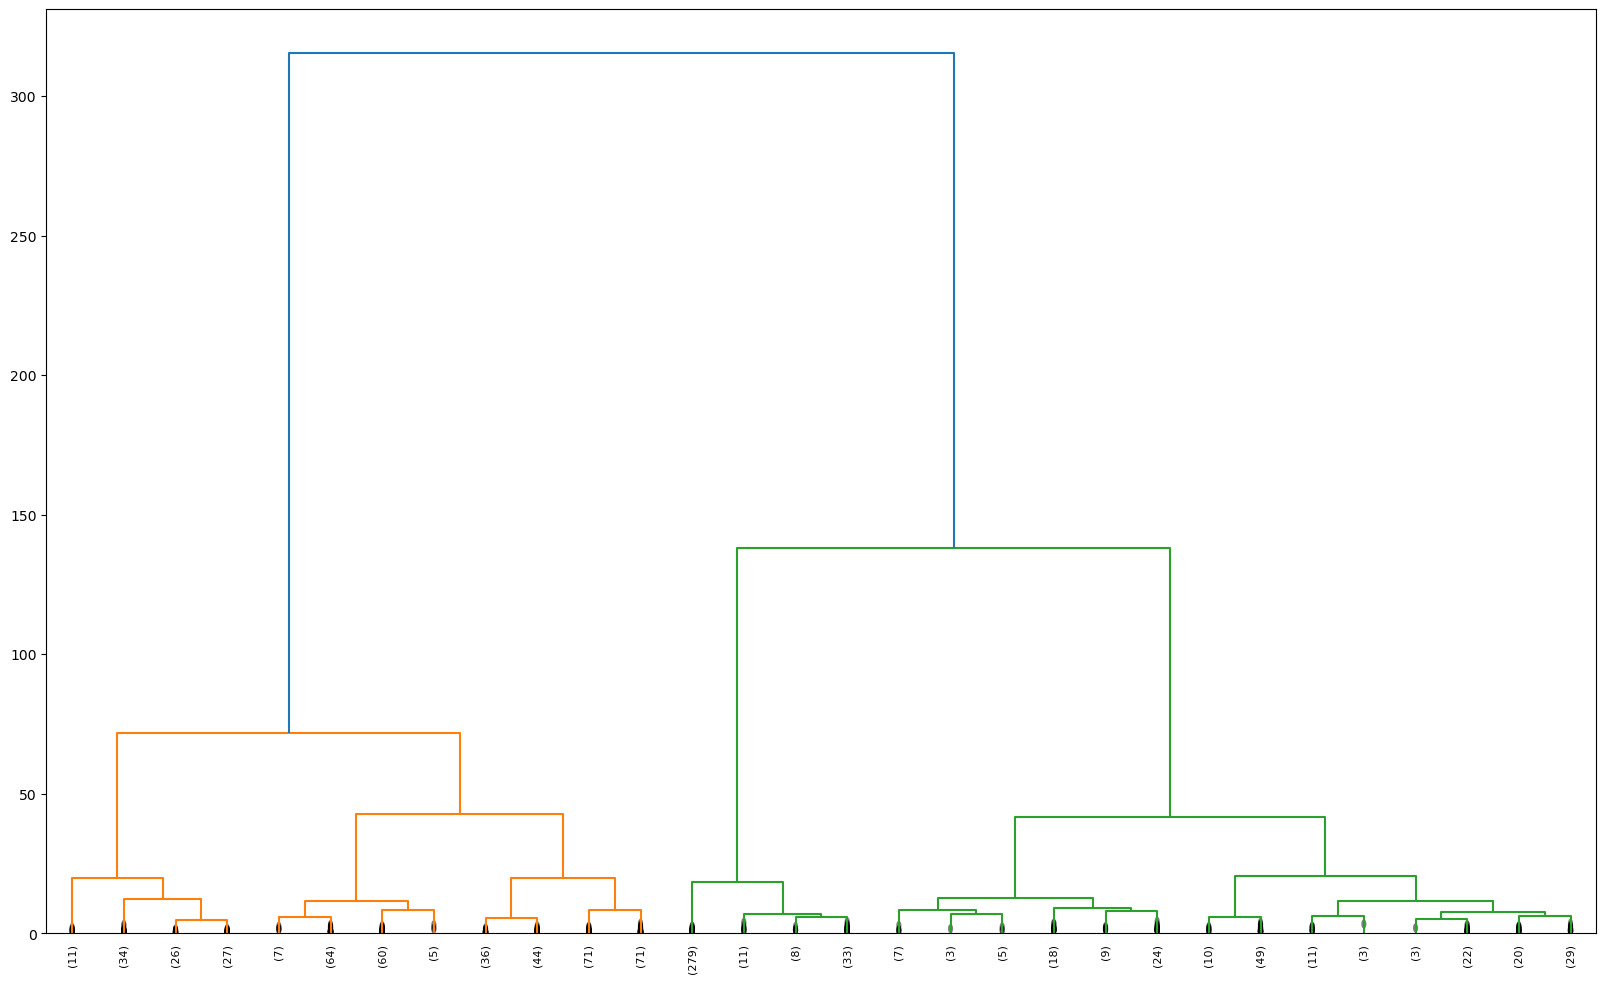

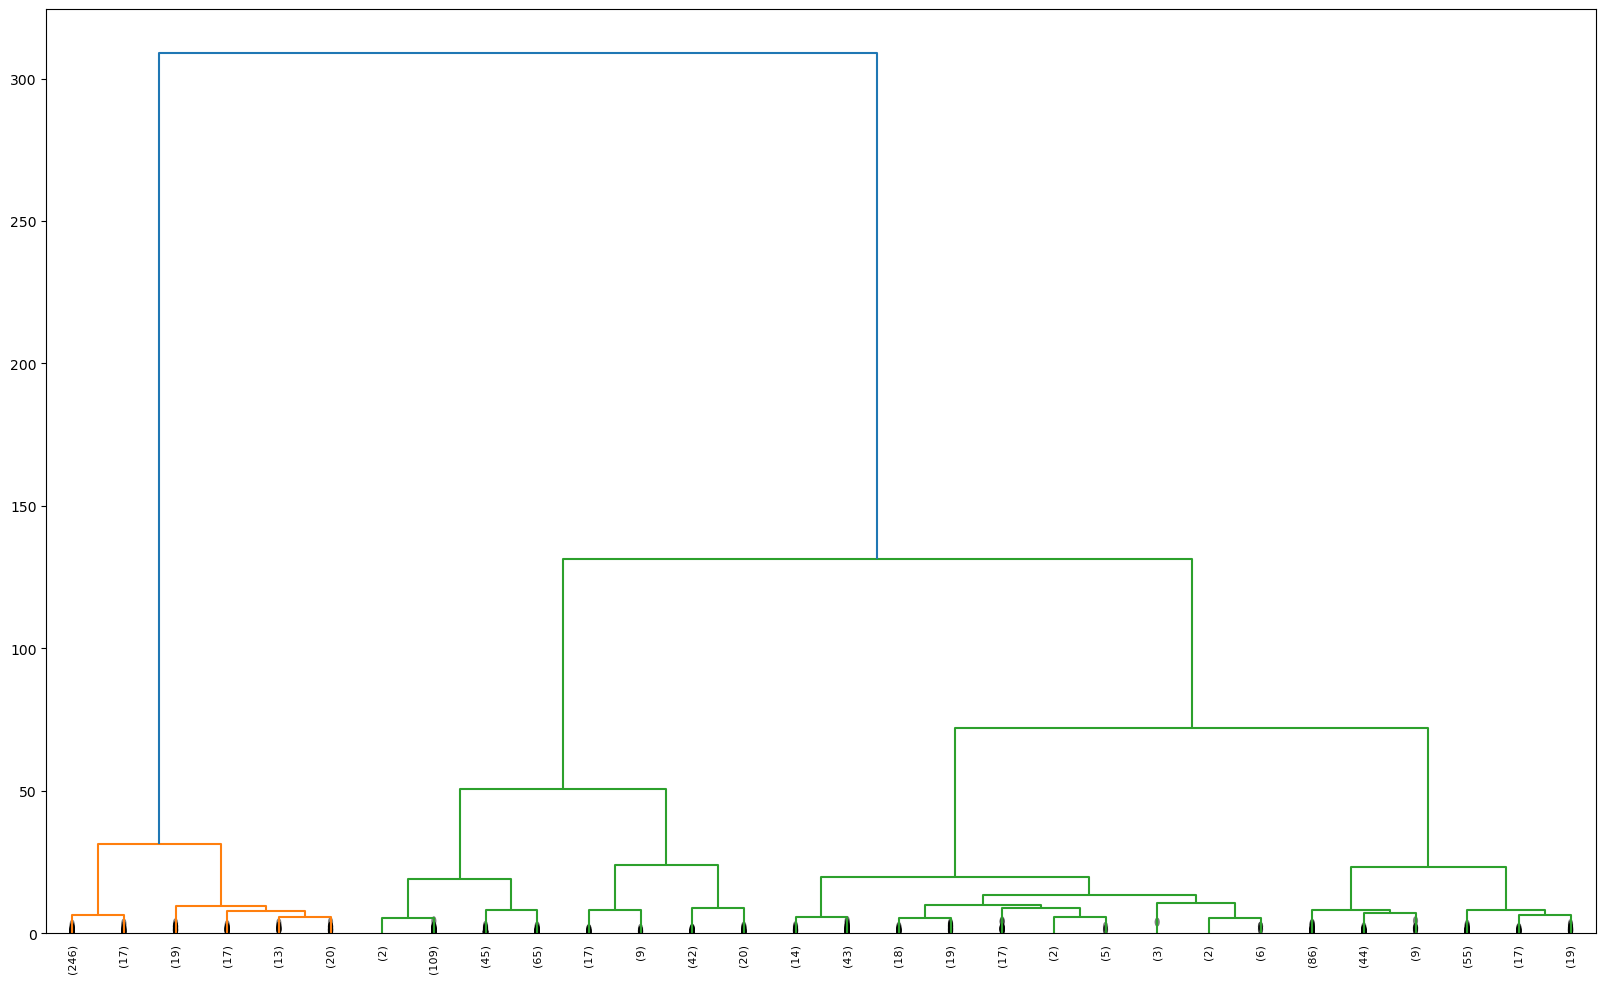

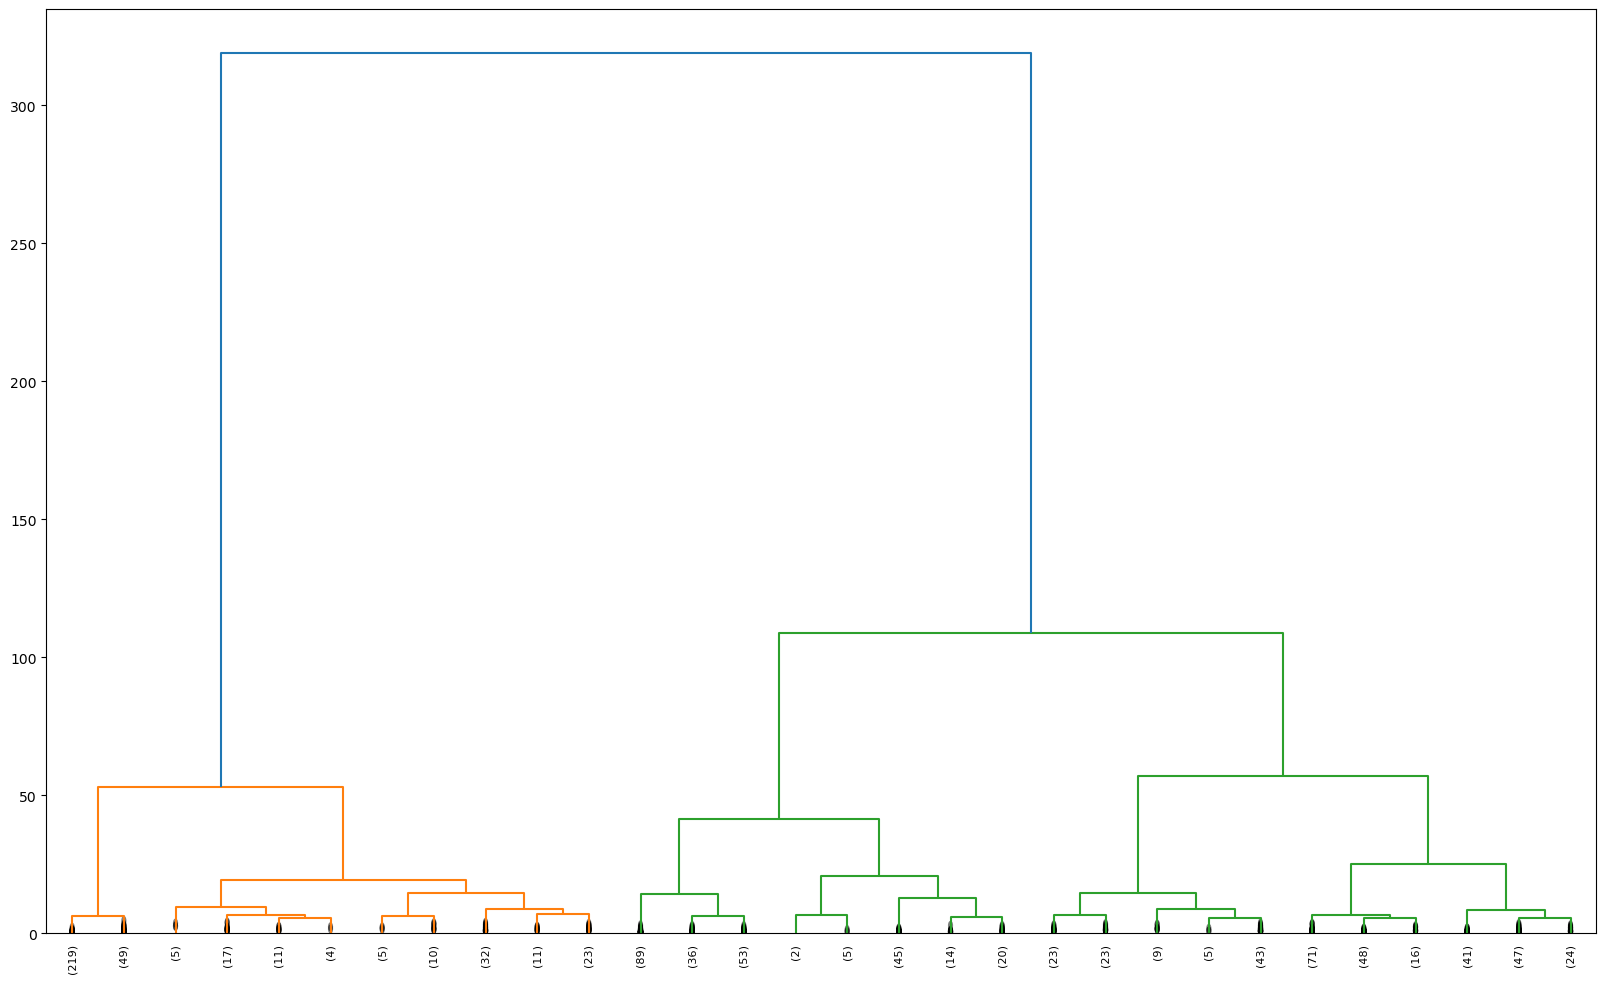

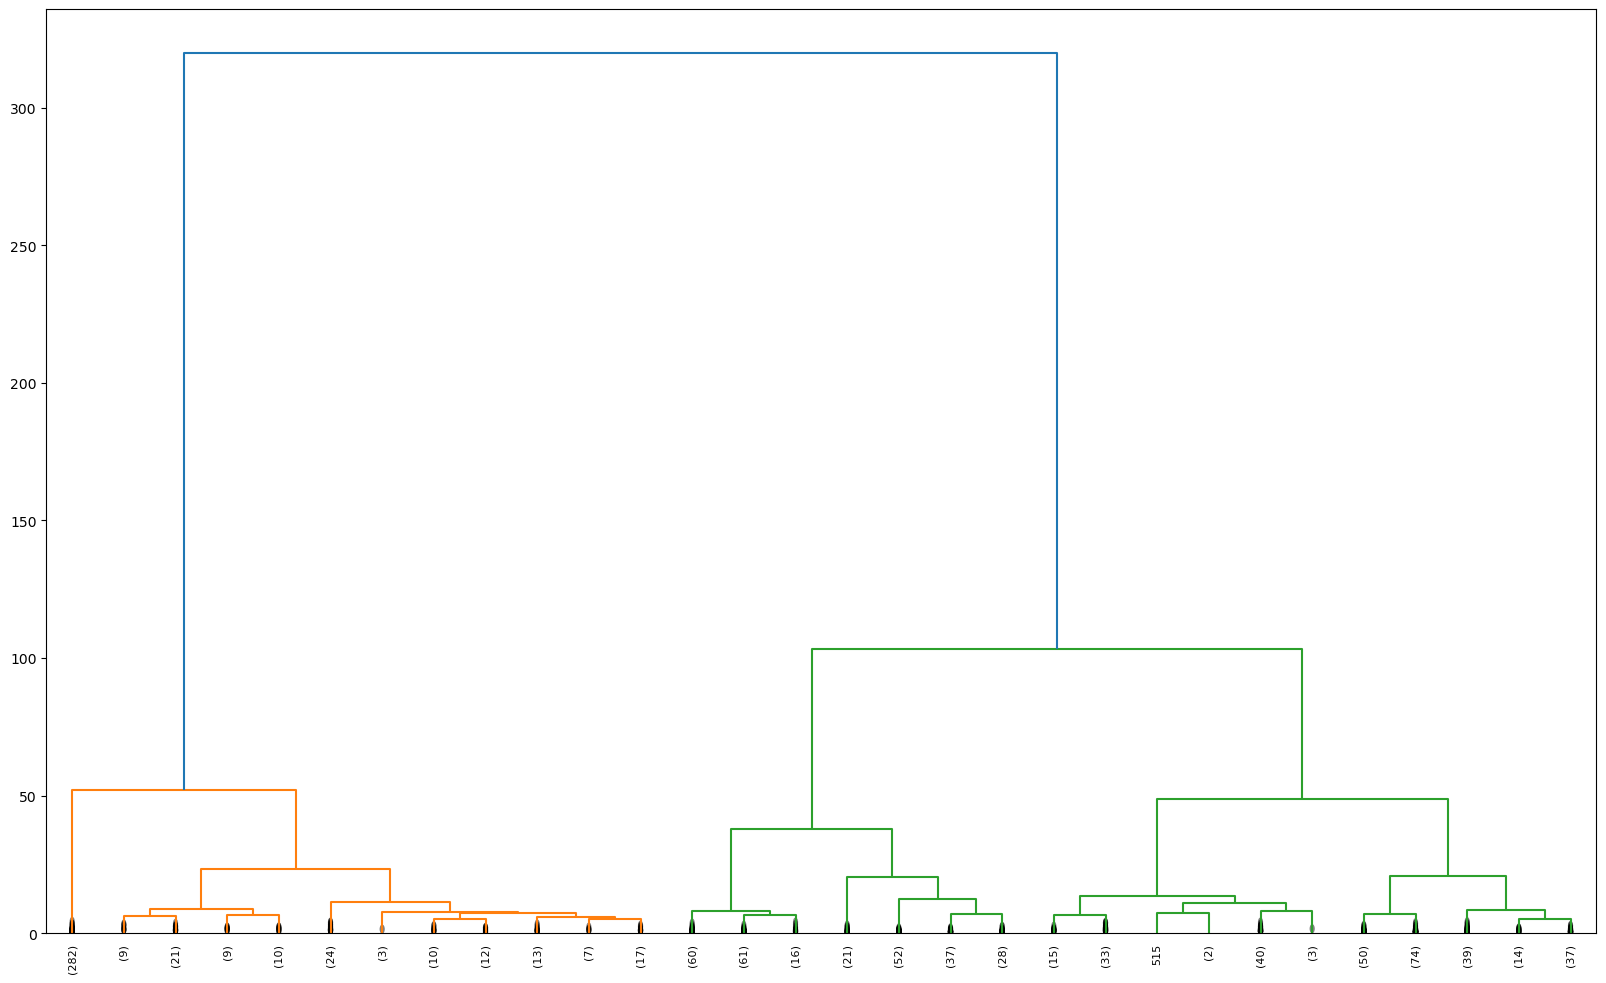

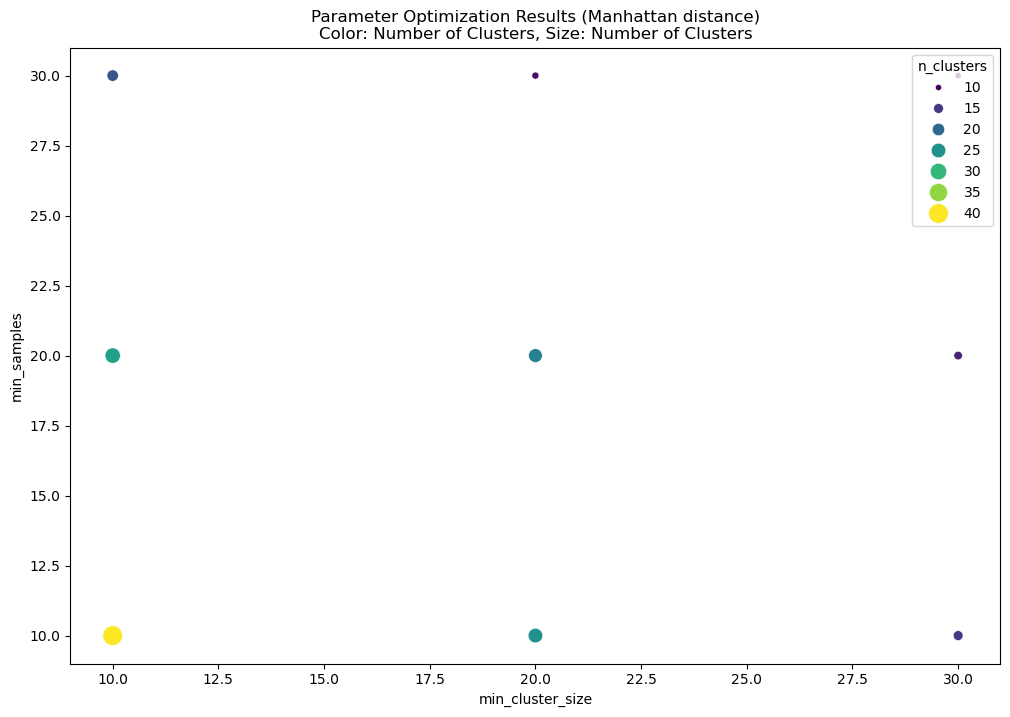

Exception ignored in: <function ResourceTracker.__del__ at 0x70f101383920>
Traceback (most recent call last):
  File "/home/shafeeq/Downloads/yes/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/shafeeq/Downloads/yes/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/shafeeq/Downloads/yes/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x74f194183920>
Traceback (most recent call last):
  File "/home/shafeeq/Downloads/yes/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/shafeeq/Downloads/yes/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/shafeeq/Downloads/yes/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import hdbscan
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import LinearSegmentedColormap
from sklearn.manifold import MDS
from sklearn.decomposition import TruncatedSVD  # Alternative for large datasets

# Create output directory
output_dir = "final_results/all_genes_optimization_manhattan"
os.makedirs(output_dir, exist_ok=True)

# Create custom red colormap
colors = [(0, 'white'), (0.5, 'lightcoral'), (1, 'darkred')]
red_cmap = LinearSegmentedColormap.from_list('red_cmap', colors)

# Assuming filtered_df is your original count matrix (genes × samples)
print(f"Original data shape: {filtered_df.shape}")

# 1. Log-normalization
normalized_data = np.log2(filtered_df + 1)

# 2. Use ALL genes instead of top variable genes
print(f"Using all genes: {normalized_data.shape}")

# 3. Z-score normalization
all_genes_scaled = pd.DataFrame(
    StandardScaler().fit_transform(normalized_data),
    index=normalized_data.index,
    columns=normalized_data.columns
)

# Parameter ranges - let's use a smaller subset for testing first
min_cluster_sizes = [10, 20, 30]
min_samples_range = [10, 20, 30]

# Store optimization results
optimization_results = []

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_range:
        print(f"\nRunning with min_cluster_size={min_cluster_size}, min_samples={min_samples}")
        
        param_dir = os.path.join(output_dir, f"min_cluster_{min_cluster_size}_min_samples_{min_samples}")
        os.makedirs(param_dir, exist_ok=True)
        
        # HDBSCAN clustering with Manhattan distance
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            gen_min_span_tree=True,
            metric='manhattan'
        )
        clusters = clusterer.fit_predict(all_genes_scaled)
        
        # Store results
        optimization_results.append({
            'min_cluster_size': min_cluster_size,
            'min_samples': min_samples,
            'n_clusters': len(set(clusters)) - (1 if -1 in clusters else 0),
            'n_noise': sum(clusters == -1)
        })
        
        # Create cluster assignment dataframe
        cluster_assignments = pd.DataFrame({
            'Gene': all_genes_scaled.index,
            'Cluster': clusters
        })
        cluster_assignments.to_csv(
            os.path.join(param_dir, "all_gene_cluster_assignments.csv"),
            index=False
        )
        
        # Generate heatmaps for each cluster (including -1)
        for cluster_id in np.unique(clusters):
            cluster_name = "Outliers" if cluster_id == -1 else f"Cluster_{cluster_id}"
            cluster_genes = cluster_assignments[cluster_assignments['Cluster'] == cluster_id]['Gene']
            
            if len(cluster_genes) > 0:
                # Save gene list
                pd.DataFrame({'Gene': cluster_genes}).to_csv(
                    os.path.join(param_dir, f"{cluster_name}_genes.csv"),
                    index=False
                )
                
                # Create heatmap for this cluster (only if not too large)
                if len(cluster_genes) <= 1000:  # Limit heatmap size
                    cluster_data = all_genes_scaled.loc[cluster_genes]
                    
                    plt.figure(figsize=(15, 10))
                    gs = plt.GridSpec(2, 1, height_ratios=[0.9, 0.1])
                    ax0 = plt.subplot(gs[0])
                    ax1 = plt.subplot(gs[1])
                    
                    sns.heatmap(
                        cluster_data,
                        cmap=red_cmap,
                        yticklabels=False,
                        cbar=False,
                        ax=ax0,
                        center=0,
                        vmin=-3,
                        vmax=3
                    )
                    ax0.set_title(f"Expression Heatmap - {cluster_name} (n={len(cluster_genes)})")
                    ax0.set_xlabel("")
                    
                    cbar = plt.colorbar(ax0.collections[0], cax=ax1, orientation='horizontal')
                    cbar.set_label('Z-score normalized expression', labelpad=10)
                    cbar.ax.xaxis.set_ticks_position('bottom')
                    cbar.ax.xaxis.set_label_position('bottom')
                    
                    plt.tight_layout()
                    plt.savefig(
                        os.path.join(param_dir, f"{cluster_name}_heatmap.png"),
                        dpi=300, bbox_inches='tight'
                    )
                    plt.close()
        
        # Use TruncatedSVD instead of MDS for large datasets
        print("Performing dimensionality reduction with TruncatedSVD...")
        svd = TruncatedSVD(n_components=2, random_state=42)
        svd_result = svd.fit_transform(all_genes_scaled)
        
        svd_df = pd.DataFrame({
            'Component1': svd_result[:, 0],
            'Component2': svd_result[:, 1],
            'Cluster': clusters
        })
        
        # 1. SVD plot for all clusters
        plt.figure(figsize=(12, 8))
        unique_clusters = np.unique(clusters)
        palette = sns.color_palette("hsv", len(unique_clusters)-1) + [(0.5, 0.5, 0.5)]
        
        sns.scatterplot(
            data=svd_df,
            x='Component1',
            y='Component2',
            hue='Cluster',
            palette=palette,
            alpha=0.7,
            s=20  # Smaller points for large dataset
        )
        plt.title(f"SVD of Gene Clusters (Manhattan distance)\n(min_cluster_size={min_cluster_size}, min_samples={min_samples})")
        plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(
            os.path.join(param_dir, "svd_all_clusters.png"),
            dpi=300, bbox_inches='tight'
        )
        plt.close()
        
        # 2. SVD plot for ONLY outliers (-1 cluster)
        if -1 in clusters:
            outliers_df = svd_df[svd_df['Cluster'] == -1]
            plt.figure(figsize=(12, 8))
            sns.scatterplot(
                data=outliers_df,
                x='Component1',
                y='Component2',
                color='gray',
                alpha=0.7,
                s=20
            )
            plt.title(f"SVD of Outlier Genes Only (Manhattan distance)\n(min_cluster_size={min_cluster_size}, min_samples={min_samples}, n={len(outliers_df)})")
            plt.tight_layout()
            plt.savefig(
                os.path.join(param_dir, "svd_outliers_only.png"),
                dpi=300, bbox_inches='tight'
            )
            plt.close()
        
        # Generate dendrogram using scipy with Manhattan distance (subsampled)
        try:
            # Subsample for dendrogram (max 1000 genes)
            sample_size = min(1000, len(all_genes_scaled))
            sample_idx = np.random.choice(len(all_genes_scaled), sample_size, replace=False)
            sample_data = all_genes_scaled.iloc[sample_idx]
            sample_clusters = clusters[sample_idx]
            
            # Use Manhattan distance for dendrogram
            distance_matrix = pdist(sample_data, 'cityblock')
            linkage_matrix = linkage(distance_matrix, 'ward')
            
            plt.figure(figsize=(20, 12))
            dendrogram(
                linkage_matrix,
                truncate_mode='lastp',
                p=min(30, len(sample_data)),
                show_leaf_counts=True,
                leaf_rotation=90,
                leaf_font_size=8,
                show_contracted=True,
                color_threshold=0.7*max(linkage_matrix[:, 2])
            )
            
            # Add cluster colors
            cluster_colors = [sns.color_palette("hsv", len(set(sample_clusters)))[i] 
                            if i != -1 else (0.5, 0.5, 0.5)
                            for i in sample_clusters]
            ax = plt.gca()
            xlbls = ax.get_xmajorticklabels()
            for lbl, color in zip(xlbls, cluster_colors):
                lbl.set_color(color)
            
            plt.title(f"Gene Cluster Dendrogram (Manhattan distance)\n(min_cluster_size={min_cluster_size}, min_samples={min_samples})")
            plt.xlabel("Gene Clusters")
            plt.ylabel("Manhattan Distance")
            plt.savefig(
                os.path.join(param_dir, "gene_cluster_dendrogram.png"),
                dpi=300, bbox_inches='tight'
            )
            plt.close()
        except Exception as e:
            print(f"Could not create dendrogram: {e}")

# Save optimization results
optimization_df = pd.DataFrame(optimization_results)
optimization_df.to_csv(os.path.join(output_dir, "parameter_optimization_results.csv"), index=False)

# Plot optimization summary
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=optimization_df,
    x='min_cluster_size',
    y='min_samples',
    size='n_clusters',
    hue='n_clusters',
    palette='viridis',
    sizes=(20, 200)
)
plt.title("Parameter Optimization Results (Manhattan distance)\nColor: Number of Clusters, Size: Number of Clusters")
plt.colorbar(label='Number of Clusters')
plt.savefig(os.path.join(output_dir, "parameter_optimization_summary.png"), dpi=300)
plt.close()

print(f"\nAll results saved to: {output_dir}")